# 03 — Experiment 2: Voluntary Breath Hold & The Confounding Effect of Conscious Effort

本階段實驗原先設計為兩次重複的閉氣測試：`E2A_insp_1/2` (吸氣閉氣) 與 `E2B_exp_1/2` (呼氣閉氣)。
但在初步分析中，我們發現受試者的「主觀努力程度 (Subjective Effort)」在兩次 Trial 間存在顯著差異，進而成為自律神經分析中極具價值的干擾變項 (Confounding Factor)。

**重新定義的分析框架：**
- **Trial 1 (`_1`) = Effortful Hold:** 伴隨較大的意志力支撐、輕微不適感與 Valsalva-like 胸腔壓力變化。
- **Trial 2 (`_2`) = Relaxed Hold:** 較放鬆的閉氣，接近純粹的呼吸停止 (Pure respiratory cessation)。

**Deliverables (更新版):**
- **Fig 2.1 (Verification):** 驗證 HF 的生理性塌陷 (E1B vs. Hold)。
- **Fig 2.2 (The Conflict):** 意志力對自律神經的污染 (Effortful vs. Relaxed 的 Tachogram & PSD 對比)。
- **Fig 2.3 (Pure Physiology):** 排除意志力干擾後，吸氣與呼氣閉氣的真實血流動力學差異 (只取 Trial 2)。
- **Table 2.1:** 依據 Condition × Effort 分層的 HRV 量化摘要表。

In [1]:
# ==========================================
# Cell 1: Setup & IEEE TBME Styling
# ==========================================
from __future__ import annotations

import sys
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

REPO_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src import config as cfg
from src import pipeline as P
from src import plotting as PL

# 強制導入 IEEE TBME 繪圖標準
def apply_ieee_tbme_style():
    PL.apply_style() # 先套用基礎風格
    plt.rcParams.update({
        "font.family": "serif",
        "font.serif": ["Times New Roman"],
        "font.size": 8,
        "axes.labelsize": 8,
        "axes.titlesize": 9,
        "xtick.labelsize": 7,
        "ytick.labelsize": 7,
        "legend.fontsize": 7,
        "figure.titlesize": 10,
        "lines.linewidth": 0.8,
        "axes.linewidth": 0.6,
        "figure.dpi": 300,
        "savefig.dpi": 300,
        "savefig.format": "png"
    })

apply_ieee_tbme_style()
warnings.filterwarnings('ignore', category=RuntimeWarning)


def _panel_label(ax, text, pad=6):
    """Left-aligned bold panel title (A., B., …) for multi-panel figures."""
    ax.set_title(text, loc="left", fontweight="bold", fontsize=9, pad=pad)


FIG_DIR = REPO_ROOT / 'outputs' / 'paper_figures_png'
TBL_DIR = REPO_ROOT / 'outputs' / 'tables'
FIG_DIR.mkdir(parents=True, exist_ok=True)
TBL_DIR.mkdir(parents=True, exist_ok=True)

# --- 數據載入與 Metadata 注入 ---
anchor_key = "E1B"
r_anchor = P.analyze_steady_state(anchor_key)
HF_E1B = r_anchor.fd_hrv["hf_ms2"]

E2_KEYS = ["E2A_insp_1", "E2A_insp_2", "E2B_exp_1", "E2B_exp_2"]
trials = {}
for k in E2_KEYS:
    r = P.analyze_transient_event(k)
    repetition = k.split('_')[-1]
    r.extras['effort'] = 'Effortful' if repetition == '1' else 'Relaxed'
    r.extras['condition'] = 'Inspiratory' if 'insp' in k else 'Expiratory'
    trials[k] = r

print(f'Setup complete. IEEE TBME style applied.')
print(f'Baseline (E1B) HF: {HF_E1B:.1f} ms²')

Setup complete. IEEE TBME style applied.
Baseline (E1B) HF: 1123.4 ms²


## Deliverable 1 - Verification of HF Collapse

**方法論說明：** 本圖僅使用 **Relaxed trial (Trial 2)** 進行 HF 對比。
Trial 1 (Effortful) 的 HR slope 與 Trial 2 方向相反（吸氣閉氣：−0.19 vs +0.18 bpm/s），
代表兩者屬於不同的自律神經調控狀態，不應做 ensemble averaging。
Effort 效應的詳細分析見 Deliverable 2。

=== HF Power — Relaxed Trial Only (frequency_domain_hrv) ===
E1B Anchor:           1123.4 ms²
Insp Relaxed Hold:    39.1 ms²  (÷28.8, ↓96.5%)
Exp  Relaxed Hold:    230.9 ms²  (÷4.9, ↓79.4%)
Insp Relaxed Recovery:1207.4 ms²  (×1.07)
Exp  Relaxed Recovery:1213.1 ms²  (×1.08)


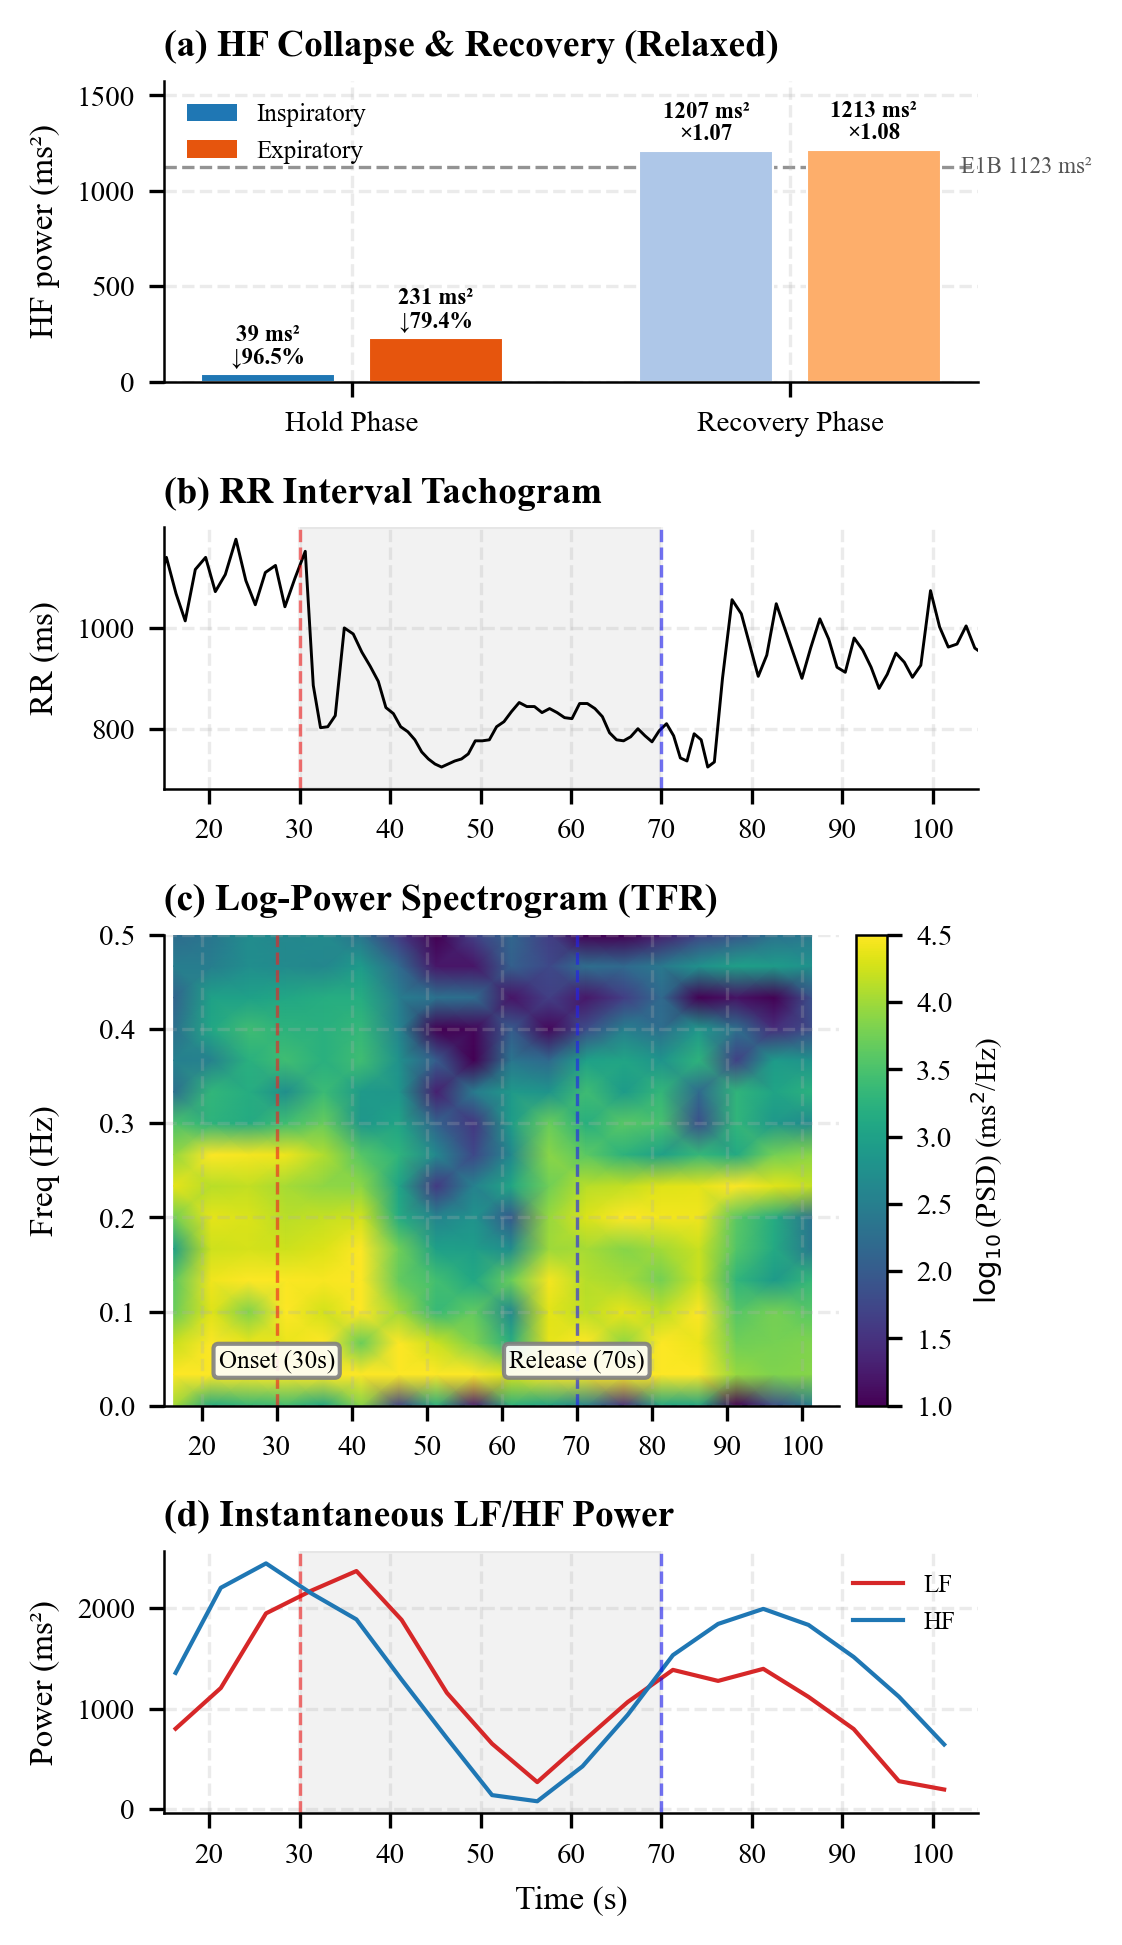

In [2]:
# ==========================================
# Cell 2: Deliverable 1 — HF Collapse & Recovery (Relaxed Trial Only)
# ==========================================
# 僅使用 Trial 2 (Relaxed)：排除 effort confound，呈現純粹呼吸停止的 HF 效應
# 頻域計算統一使用 frequency_domain_hrv (nperseg = min(256, N))，與 E1B anchor 一致
import matplotlib.transforms as mtransforms
from matplotlib.patches import Patch

# --- Relaxed trials only ---
r_insp = trials["E2A_insp_2"]   # Inspiratory Relaxed
r_exp  = trials["E2B_exp_2"]    # Expiratory Relaxed

hold_lo, hold_hi = cfg.E2_SEG['hold']       # 30–70 s
rec_lo, rec_hi   = cfg.E2_SEG['recovery']   # 70–120 s

def _phase_hf(r, t_lo, t_hi):
    """單一 trial 的 phase-specific HF power (ms²)。"""
    m = (r.rr_times_nk >= t_lo) & (r.rr_times_nk < t_hi)
    return P.frequency_domain_hrv(r.rr_ms_nk[m], r.rr_times_nk[m])['hf_ms2']

HF_insp_hold = _phase_hf(r_insp, hold_lo, hold_hi)
HF_exp_hold  = _phase_hf(r_exp,  hold_lo, hold_hi)
HF_insp_rec  = _phase_hf(r_insp, rec_lo,  rec_hi)
HF_exp_rec   = _phase_hf(r_exp,  rec_lo,  rec_hi)

print("=== HF Power — Relaxed Trial Only (frequency_domain_hrv) ===")
print(f"E1B Anchor:           {HF_E1B:.1f} ms²")
print(f"Insp Relaxed Hold:    {HF_insp_hold:.1f} ms²  (÷{HF_E1B/HF_insp_hold:.1f}, ↓{100*(1-HF_insp_hold/HF_E1B):.1f}%)")
print(f"Exp  Relaxed Hold:    {HF_exp_hold:.1f} ms²  (÷{HF_E1B/HF_exp_hold:.1f}, ↓{100*(1-HF_exp_hold/HF_E1B):.1f}%)")
print(f"Insp Relaxed Recovery:{HF_insp_rec:.1f} ms²  (×{HF_insp_rec/HF_E1B:.2f})")
print(f"Exp  Relaxed Recovery:{HF_exp_rec:.1f} ms²  (×{HF_exp_rec/HF_E1B:.2f})")

# --- Spectrogram for Panels B–D (representative: Inspiratory Relaxed) ---
r = r_insp  # representative trial for panels B–D

def smooth_series(data, window=3):
    if len(data) < window: return data
    return np.convolve(data, np.ones(window)/window, mode='same')

f_spec, t_spec, Sxx = P.rr_spectrogram(r.rr_ms_nk, r.rr_times_nk)
_mlf = (f_spec >= cfg.BANDS['LF'][0]) & (f_spec < cfg.BANDS['LF'][1])
_mhf = (f_spec >= cfg.BANDS['HF'][0]) & (f_spec < cfg.BANDS['HF'][1])
lf_t = np.trapezoid(Sxx[_mlf, :], f_spec[_mlf], axis=0) if Sxx.size else np.array([])
hf_t = np.trapezoid(Sxx[_mhf, :], f_spec[_mhf], axis=0) if Sxx.size else np.array([])

# =================== 繪圖 (IEEE 單欄 3.5" × 7.5") ===================
fig = plt.figure(figsize=(3.5, 7.5))
gs = GridSpec(4, 1, height_ratios=[1.15, 1, 1.8, 1], hspace=0.45)

# ── Panel A: HF Collapse & Recovery — Relaxed Trial Only ─────────────
ax_bar = fig.add_subplot(gs[0])

bar_w = 0.52
x_hold = np.array([0.0, 0.65])
x_rec  = np.array([1.7, 2.35])
col_insp, col_exp = '#1f77b4', '#e6550d'
col_insp_lt, col_exp_lt = '#aec7e8', '#fdae6b'

# 4 bars (no error bars: n=1, single Relaxed trial per condition)
for x, val, c in [
    (x_hold[0], HF_insp_hold, col_insp),
    (x_hold[1], HF_exp_hold,  col_exp),
    (x_rec[0],  HF_insp_rec,  col_insp_lt),
    (x_rec[1],  HF_exp_rec,   col_exp_lt),
]:
    ax_bar.bar(x, val, width=bar_w, color=c, edgecolor='white', lw=0.5, zorder=2)

# E1B reference line
ax_bar.axhline(HF_E1B, color='#666', ls='--', lw=0.8, alpha=0.7, zorder=1)
ax_bar.text(x_rec[1] + bar_w/2 + 0.08, HF_E1B,
            f'E1B {HF_E1B:.0f} ms²', fontsize=5.5, va='center', ha='left',
            color='#555', clip_on=False)

# Annotations
_ymax = max(HF_insp_rec, HF_exp_rec, HF_E1B) * 1.30
_gap = _ymax * 0.020

for x, val, label in [
    (x_hold[0], HF_insp_hold,
     f'{HF_insp_hold:.0f} ms²\n↓{100*(1 - HF_insp_hold/HF_E1B):.1f}%'),
    (x_hold[1], HF_exp_hold,
     f'{HF_exp_hold:.0f} ms²\n↓{100*(1 - HF_exp_hold/HF_E1B):.1f}%'),
    (x_rec[0], HF_insp_rec,
     f'{HF_insp_rec:.0f} ms²\n×{HF_insp_rec/HF_E1B:.2f}'),
    (x_rec[1], HF_exp_rec,
     f'{HF_exp_rec:.0f} ms²\n×{HF_exp_rec/HF_E1B:.2f}'),
]:
    ax_bar.text(x, val + _gap, label, ha='center', va='bottom',
                fontsize=5.5, fontweight='bold', linespacing=1.1)

ax_bar.set_ylim(0, _ymax)
ax_bar.set_xticks([np.mean(x_hold), np.mean(x_rec)])
ax_bar.set_xticklabels(['Hold Phase', 'Recovery Phase'], fontsize=7)
ax_bar.set_ylabel("HF power (ms²)")
ax_bar.spines['top'].set_visible(False)
ax_bar.spines['right'].set_visible(False)

leg_h = [Patch(facecolor=col_insp, label='Inspiratory'),
         Patch(facecolor=col_exp,  label='Expiratory')]
ax_bar.legend(handles=leg_h, loc='upper left', frameon=False, fontsize=6)
_panel_label(ax_bar, '(a) HF Collapse & Recovery (Relaxed)')

# ── Panel B: RR Tachogram ────────────────────────────────────────────
t_lim = [15, 105]
ax_tach = fig.add_subplot(gs[1])
ax_tach.plot(r.rr_times_nk, r.rr_ms_nk, color='k', lw=0.7)
ax_tach.set_xlim(t_lim)
ax_tach.set_ylabel("RR (ms)")
_panel_label(ax_tach, '(b) RR Interval Tachogram')

# ── Panel C: Spectrogram ─────────────────────────────────────────────
ax_spec = fig.add_subplot(gs[2], sharex=ax_tach)
_Z = np.log10(Sxx + 1e-12)
mesh = ax_spec.pcolormesh(t_spec, f_spec, _Z, shading='gouraud', cmap='viridis', vmin=1, vmax=4.5)
ax_spec.set_ylim(0, 0.5)
ax_spec.set_ylabel('Freq (Hz)')
cb = plt.colorbar(mesh, ax=ax_spec, pad=0.02, aspect=15)
cb.set_label(r'$\log_{10}$(PSD) (ms$^2$/Hz)', fontsize=7)
_panel_label(ax_spec, '(c) Log-Power Spectrogram (TFR)')

_tmix = mtransforms.blended_transform_factory(ax_spec.transData, ax_spec.transAxes)
ev_style = dict(fontsize=6, ha='center', va='bottom', family='serif',
                bbox=dict(boxstyle='round,pad=0.2', facecolor='white', edgecolor='0.5', alpha=0.9))
ax_spec.text(30, 0.07, 'Onset (30s)', transform=_tmix, **ev_style)
ax_spec.text(70, 0.07, 'Release (70s)', transform=_tmix, **ev_style)

# ── Panel D: Instantaneous Power ─────────────────────────────────────
ax_trk = fig.add_subplot(gs[3], sharex=ax_tach)
if t_spec.size:
    ax_trk.plot(t_spec, smooth_series(lf_t), color='C3', label='LF', lw=1)
    ax_trk.plot(t_spec, smooth_series(hf_t), color='C0', label='HF', lw=1)
ax_trk.set_ylabel('Power (ms²)')
ax_trk.set_xlabel('Time (s)')
ax_trk.legend(loc='upper right', frameon=False, fontsize=6)
_panel_label(ax_trk, '(d) Instantaneous LF/HF Power')

for ax in [ax_tach, ax_spec, ax_trk]:
    ax.axvspan(30, 70, color='gray', alpha=0.1, zorder=0)
    ax.axvline(30, color='red', ls='--', lw=0.8, alpha=0.5)
    ax.axvline(70, color='blue', ls='--', lw=0.8, alpha=0.5)

fig.align_ylabels()
PL.save_figure(fig, "nb03_fig01_e2_hf_collapse.pdf")
plt.show()

## Deliverable 2 - Effort vs. Relaxed (The Confounding Factor)

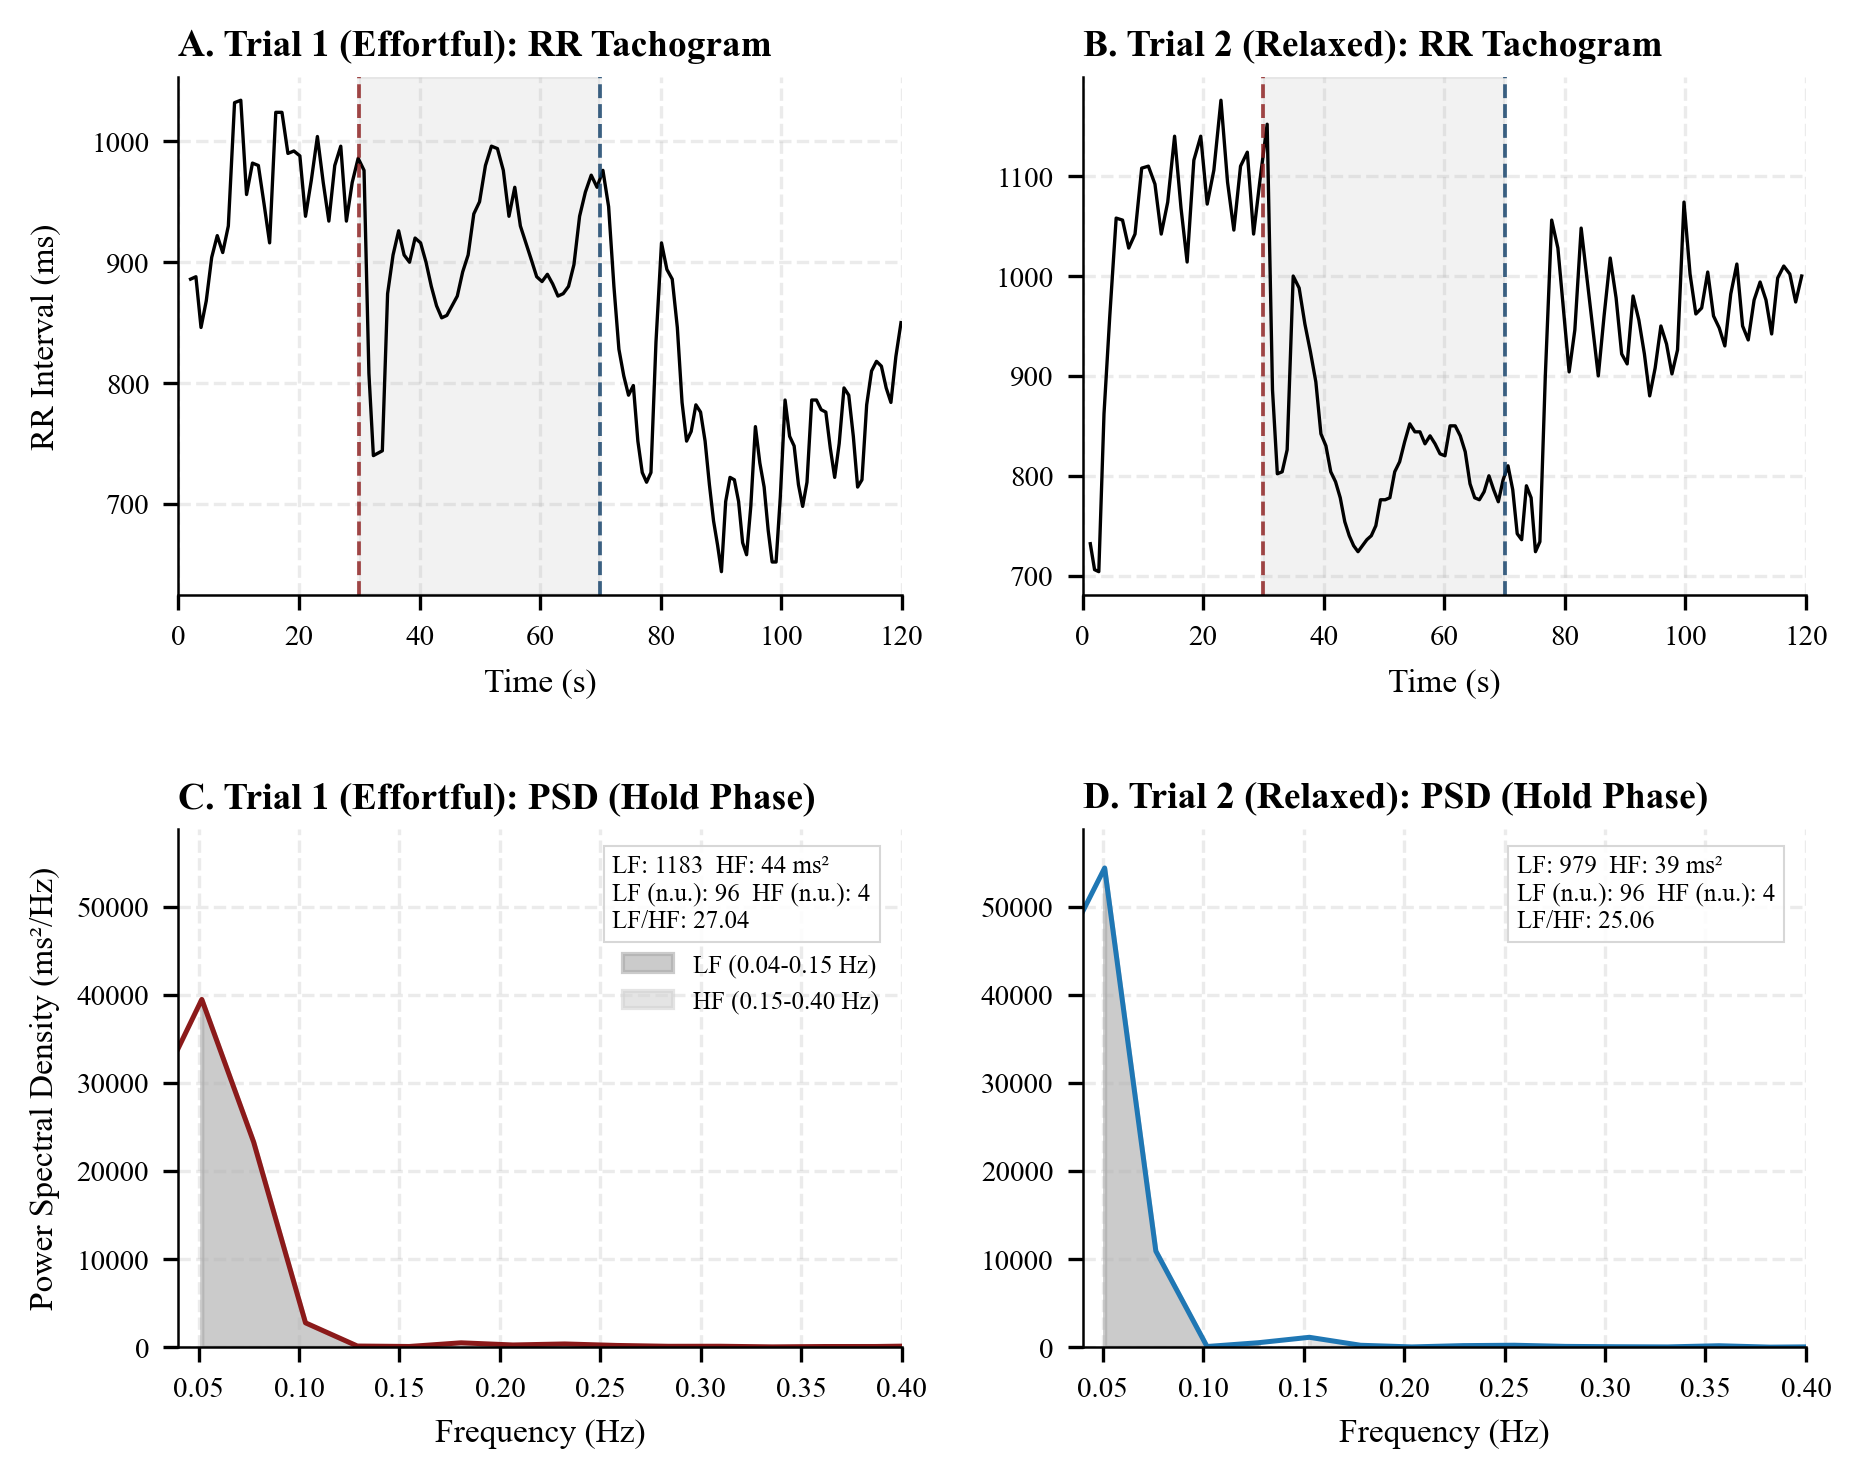

In [3]:
# ==========================================
# Cell 3: Deliverable 2 - Effort vs. Relaxed Analysis (Optimized)
# ==========================================
# 移除 sharex='col'，因為上下排的 X 軸物理意義不同 (時間 vs. 頻率)
fig, axes = plt.subplots(2, 2, figsize=(7.0, 5.5))
plt.subplots_adjust(hspace=0.45, wspace=0.25)

panel_labels = [['A', 'B'], ['C', 'D']]

# Hold-phase PSD 預先算好，供兩 panel 共用線性 y 軸上界（與 Exp1 綜合 PSD 圖 d–f 相同做法）
_holds: dict = {}
for _rep in ['1', '2']:
    _r = trials[f"E2A_insp_{_rep}"]
    _hm = (_r.rr_times_nk >= 30) & (_r.rr_times_nk <= 70)
    _rr, _rt = _r.rr_ms_nk[_hm], _r.rr_times_nk[_hm]
    _f, _p = P.rr_psd(_rr, _rt)
    _holds[_rep] = (_r, _f, _p, P.frequency_domain_hrv(_rr, _rt))
global_max_psd = 0.0
for _rep in ['1', '2']:
    _f, _p = _holds[_rep][1], _holds[_rep][2]
    _m = (_f >= 0.04) & (_f <= 0.5)
    if _m.any():
        global_max_psd = max(global_max_psd, float(np.max(_p[_m])))
global_max_psd *= 1.45

for i, rep in enumerate(['1', '2']):
    r, f, p, fd = _holds[rep]
    effort = r.extras['effort']
    color_theme = '#8b1a1a' if effort == 'Effortful' else '#1f77b4' # 紅色系 vs 藍色系
    
    # --- Row 1: RR Tachogram ---
    ax_rr = axes[0, i]
    ax_rr.plot(r.rr_times_nk, r.rr_ms_nk, color='black', lw=0.8)
    
    # 加入與 Fig 2.1 相同的 Hold 區間標示
    ax_rr.axvspan(30, 70, color='gray', alpha=0.1)
    ax_rr.axvline(30, color='#8b1a1a', linestyle='--', linewidth=0.9, alpha=0.8)
    ax_rr.axvline(70, color='#0d3c66', linestyle='--', linewidth=0.9, alpha=0.8)
    
    ax_rr.set_xlim(0, 120)
    if i == 0: ax_rr.set_ylabel("RR Interval (ms)")
    ax_rr.set_xlabel("Time (s)")
    
    title_text = f"Trial {rep} ({effort})"
    _panel_label(ax_rr, f"{panel_labels[0][i]}. {title_text}: RR Tachogram", pad=5)
    
    # --- Row 2: PSD during Hold；半開區間 [lo,hi) 與 pipeline / Exp1 一致
    ax_psd = axes[1, i]
    _lo_lf, _hi_lf = cfg.BANDS['LF']
    _lo_hf, _hi_hf = cfg.BANDS['HF']
    m_lf = (f >= _lo_lf) & (f < _hi_lf)
    m_hf = (f >= _lo_hf) & (f < _hi_hf)
    # 曲線下方面積填色僅在線性 y 有意義；灰階與 Exp1 綜合 PSD 圖 d–f 一致
    ax_psd.fill_between(f, 0, p, where=m_lf, color='#A9A9A9', alpha=0.6, zorder=1,
                        label='LF (0.04-0.15 Hz)')
    ax_psd.fill_between(f, 0, p, where=m_hf, color='#D3D3D3', alpha=0.6, zorder=1,
                        label='HF (0.15-0.40 Hz)')
    ax_psd.plot(f, p, color=color_theme, lw=1.2, zorder=2)
    ax_psd.set_xlim(0.04, 0.4)
    ax_psd.set_ylim(0, global_max_psd-20000)
    if i == 0: ax_psd.set_ylabel("Power Spectral Density (ms²/Hz)")
    ax_psd.set_xlabel("Frequency (Hz)")
    
    _panel_label(ax_psd, f"{panel_labels[1][i]}. {title_text}: PSD (Hold Phase)", pad=5)
    
    # 頻域指標：與 Exp1 comprehensive PSD 格、pipeline HRV 表同一定義 (Welch 積分)
    _lhr = fd['lf_hf_ratio']
    _lhr_s = f"{_lhr:.2f}" if np.isfinite(_lhr) else "—"
    fd_text = (
        f"LF: {fd['lf_ms2']:.0f}  HF: {fd['hf_ms2']:.0f} ms²\n"
        f"LF (n.u.): {fd['lf_nu']:.0f}  HF (n.u.): {fd['hf_nu']:.0f}\n"
        f"LF/HF: {_lhr_s}"
    )
    ax_psd.text(0.60, 0.95, fd_text, transform=ax_psd.transAxes, fontsize=6,
                verticalalignment='top', horizontalalignment='left',
                bbox=dict(boxstyle='square,pad=0.35', facecolor='white', alpha=0.9,
                          edgecolor='lightgray', lw=0.5))
    
    # 只在 Panel C 放置圖例
    if i == 0:
        # 使用 bbox_to_anchor 指定一個介於 'center right' (0.5) 和 'upper right' (1.0) 之間的 y 座標，例如設為 0.75
        ax_psd.legend(loc='center right', bbox_to_anchor=(1, 0.70), frameon=False, fontsize=6)
 

fig.align_ylabels(axes[:, 0])
plt.savefig(FIG_DIR / "MAIN_06_nb03_exp2_effort_comparison.png", dpi=300, bbox_inches='tight')
plt.show()

## Deliverable 3 & 4 - Pure Physiology & Table

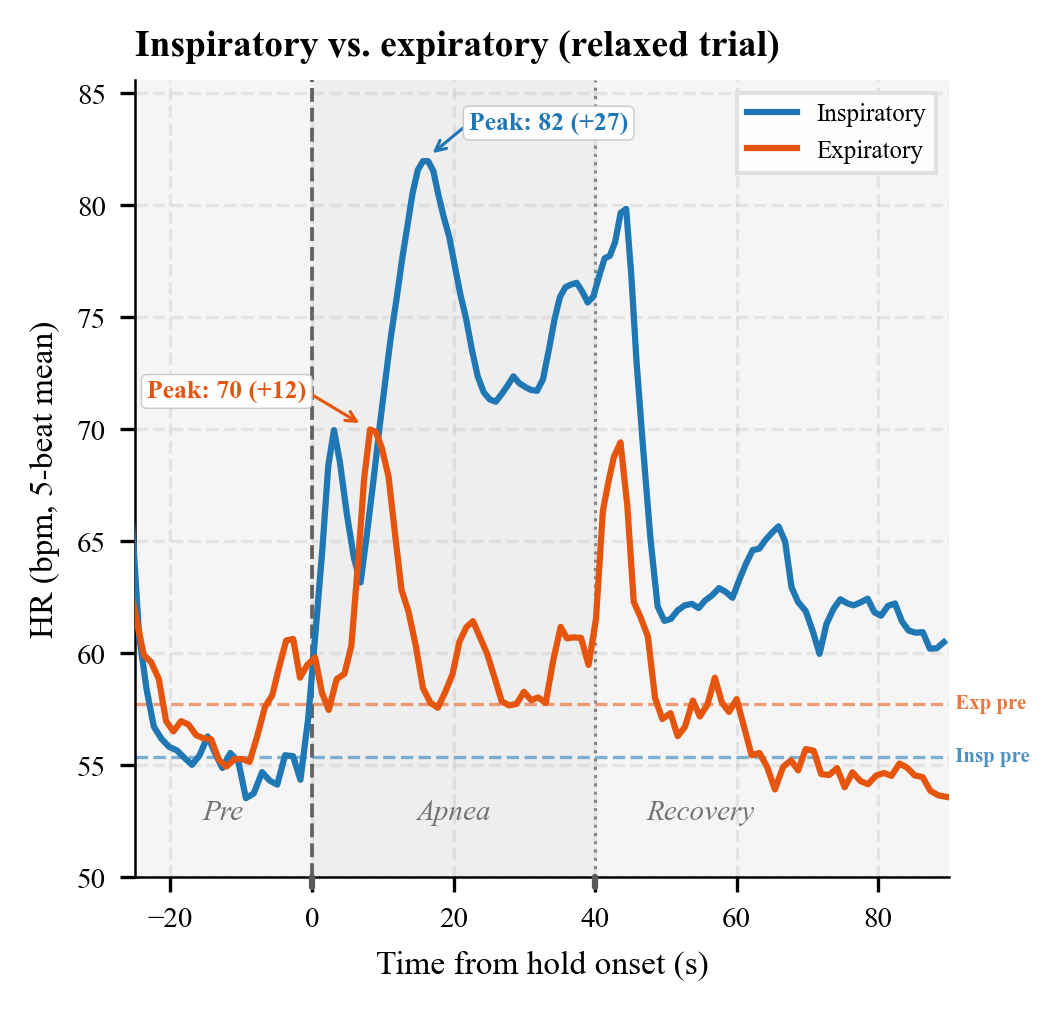

In [4]:
# ==========================================
# Cell 4: Deliverable 3 & 4 - Pure Physiology & Table
# ==========================================
# 與 pipeline 之 trial 時間軸一致: pre 5–30 s (skip settling), hold 30–70 s, recovery 70–120 s
_HOLD_ONSET_ABS, _HOLD_END_ABS = 30, 70
_PRE_LO_ABS, _PRE_HI_ABS = cfg.E2_SEG['pre']   # (5.0, 30.0) — skip first 5 s settling
_REC_LO_ABS, _REC_HI_ABS = cfg.E2_SEG['recovery']  # (70.0, 120.0)
_HOLD_DUR = _HOLD_END_ABS - _HOLD_ONSET_ABS
_SMOOTH_BEATS = 5  # 僅畫 5 拍滾動平均；逐拍由 caption / 方法說明

# 繪製 HR 軌跡
from matplotlib.transforms import blended_transform_factory

fig, ax = plt.subplots(figsize=(3.5, 3.45))
ax.set_axisbelow(True)

# 三個 regime 背景色
ax.axvspan(_PRE_LO_ABS - _HOLD_ONSET_ABS, 0,
           color="#e8e8e8", alpha=0.4, zorder=0, lw=0, label="_")
ax.axvspan(0, _HOLD_DUR,
           color="#d0d0d0", alpha=0.35, zorder=0, lw=0, label="_")
ax.axvspan(_HOLD_DUR, _REC_HI_ABS - _HOLD_ONSET_ABS,
           color="#e8e8e8", alpha=0.4, zorder=0, lw=0, label="_")
ax.axvline(0, color="#4a4a4a", ls="--", lw=0.9, zorder=1, alpha=0.85)
ax.axvline(_HOLD_DUR, color="#4a4a4a", ls=":", lw=0.75, zorder=1, alpha=0.6)

# Trial 2 單一軌跡，非多 trial 平均；無 SEM
_peak_bbox = dict(
    boxstyle="round,pad=0.22", facecolor="white", edgecolor="0.78", alpha=0.92, linewidth=0.35,
)

for _i, (key, color, leg_main, pre_tag) in enumerate(
    zip(
        ["E2A_insp_2", "E2B_exp_2"],
        ["#1f77b4", "#e6550d"],
        ["Inspiratory", "Expiratory"],
        ["Insp", "Exp"],
    )
):
    r = trials[key]
    t = r.rr_times_nk - _HOLD_ONSET_ABS
    _pre_m = (r.rr_times_nk >= _PRE_LO_ABS) & (r.rr_times_nk < _PRE_HI_ABS)
    _hr = 60000.0 / r.rr_ms_nk
    pre_mean_bpm = float(np.mean(_hr[_pre_m])) if np.any(_pre_m) else float("nan")
    hr_sm = (
        pd.Series(_hr)
        .rolling(_SMOOTH_BEATS, min_periods=1, center=True)
        .mean()
        .to_numpy()
    )

    _hold_m = (r.rr_times_nk >= _HOLD_ONSET_ABS) & (r.rr_times_nk < _HOLD_END_ABS)
    _hr_hold = hr_sm[_hold_m] if np.any(_hold_m) else np.array([])

    ax.plot(
        [-30, 90],
        [pre_mean_bpm, pre_mean_bpm],
        color=color,
        ls="--",
        lw=0.8,
        zorder=2,
        alpha=0.55,
        label="_",
    )
    ax.text(90.2, pre_mean_bpm, f" {pre_tag} pre", color=color, fontsize=5, ha="left", va="center", alpha=0.8, zorder=4, clip_on=False, fontweight="bold")

    ax.plot(t, hr_sm, color=color, lw=1.5, zorder=3, label=leg_main)

    if _hr_hold.size > 0:
        _peak_idx = int(np.argmax(_hr_hold))
        _t_hold = t[_hold_m]
        _peak_t = _t_hold[_peak_idx]
        _peak_val = _hr_hold[_peak_idx]
        _delta = _peak_val - pre_mean_bpm
        _tx = _peak_t + (6.5 if _i == 0 else -9.0)
        _ty = _peak_val + 1.2
        ax.annotate(
            f"Peak: {_peak_val:.0f} ({_delta:+.0f})",
            xy=(_peak_t, _peak_val),
            xytext=(_tx, _ty),
            fontsize=6.2,
            color=color,
            fontweight="bold",
            ha="left" if _i == 0 else "right",
            va="bottom",
            bbox=_peak_bbox,
            arrowprops=dict(
                arrowstyle="->",
                color=color,
                lw=0.75,
                shrinkA=0,
                shrinkB=3,
                relpos=(0.0, 0.5) if _i == 0 else (1.0, 0.5),
            ),
            zorder=4,
        )


# Regime 標籤
_ymin_tmp, _ymax_tmp = ax.get_ylim()
_y_label = _ymin_tmp + 0.01 * (_ymax_tmp - _ymin_tmp)
for _txt, _cx in [("Pre", -12.5), ("Apnea", 20), ("Recovery", 55)]:
    ax.text(
        _cx, _y_label, _txt,
        ha="center", va="bottom", fontsize=7, color="0.45",
        fontstyle="italic", zorder=1, clip_on=True,
    )

ax.set_xlim(-25, 90)
ax.set_ylim(50, None)
ax.set_xlabel("Time from hold onset (s)")
ax.set_ylabel("HR (bpm, 5-beat mean)")

# 0 s、40 s：加粗之 x 軸刻度小線
_xtrans = blended_transform_factory(ax.transData, ax.transAxes)
for _xv in (0, _HOLD_DUR):
    ax.plot(
        [_xv, _xv], [-0.012, 0.0], transform=_xtrans, color="0.35", lw=1.5,
        solid_capstyle="round", clip_on=False, zorder=6,
    )

ax.legend(
    frameon=True,
    loc="upper right",
    framealpha=0.96,
    edgecolor="0.88",
    fancybox=False,
    fontsize=6,
)
ax.set_title("Inspiratory vs. expiratory (relaxed trial)", loc="left")
plt.savefig(FIG_DIR / "MAIN_07_nb03_exp2_pure_physiology.png", dpi=300, bbox_inches="tight")
plt.show()

## Table 2.1 — Condition × Effort HRV 精簡摘要 (7 欄)

In [5]:

# ==========================================
# Table 2.1 — Condition × Effort HRV 精簡摘要 (7 欄)
# ==========================================
# 精簡原則：每欄必須直接對應一個論證角色
#   Hold HR + Slope  → ③ 吸/呼氣純生理差異
#   Pre HF + Hold HF → ① HF 塌陷（呼吸停止 → RSA 消失）
#   LF/HF            → ② 意志力 Valsalva-like 交感污染
#
# 砍掉的欄位：Pre HR（文字帶過）、RMSSD（與 HF 重疊）、Hold LF（LF/HF 已涵蓋）

def _fmt(val, spec=".1f"):
    return f"{val:{spec}}" if np.isfinite(val) else "—"

stats_list = []

# E1B 安靜基線參照列
_e1b_fd = r_anchor.fd_hrv
stats_list.append({
    "Condition":     "Baseline",
    "Effort":        "E1B",
    "Hold HR (bpm)": _fmt(r_anchor.td_hrv['mean_hr_bpm']),
    "Slope (bpm/s)": "—",
    "Pre HF (ms²)":  "—",
    "Hold HF (ms²)": _fmt(_e1b_fd['hf_ms2']),
    "LF/HF":         _fmt(_e1b_fd['lf_hf_ratio'], '.2f'),
})

# 4 個閉氣 Trial
for k, r in trials.items():
    th_hold = r.extras["transient_hrv"]["hold"]
    m_pre  = (r.rr_times_nk >= _PRE_LO_ABS) & (r.rr_times_nk < _PRE_HI_ABS)
    m_hold = (r.rr_times_nk >= _HOLD_ONSET_ABS) & (r.rr_times_nk < _HOLD_END_ABS)
    fd_pre  = P.frequency_domain_hrv(r.rr_ms_nk[m_pre],  r.rr_times_nk[m_pre])
    fd_hold = P.frequency_domain_hrv(r.rr_ms_nk[m_hold], r.rr_times_nk[m_hold])

    stats_list.append({
        "Condition":     r.extras['condition'],
        "Effort":        r.extras['effort'],
        "Hold HR (bpm)": _fmt(th_hold['mean_hr_bpm']),
        "Slope (bpm/s)": f"{th_hold['hr_slope_bpm_per_s']:+.3f}",
        "Pre HF (ms²)":  _fmt(fd_pre['hf_ms2']),
        "Hold HF (ms²)": _fmt(fd_hold['hf_ms2']),
        "LF/HF":         _fmt(fd_hold['lf_hf_ratio'], '.2f'),
    })

df_final = pd.DataFrame(stats_list)
display(df_final)
df_final.to_csv(TBL_DIR / "table_e2_summary.csv", index=False)

,Condition,Effort,Hold HR (bpm),Slope (bpm/s),Pre HF (ms²),Hold HF (ms²),LF/HF
0,Baseline,E1B,56.1,—,—,1123.4,0.53
1,Inspiratory,Effortful,66.9,-0.188,625.6,43.7,27.04
2,Inspiratory,Relaxed,73.5,+0.176,1523.7,39.1,25.06
3,Expiratory,Effortful,57.8,-0.098,889.9,111.3,4.79
4,Expiratory,Relaxed,60.8,-0.113,438.5,230.9,6.87
